### 1.4.3.4. Logistic Population Model

$$
\frac{dP}{dt} = P(a - bP) \;\Longrightarrow\;
P(t) = \frac{aP_0}{bP_0 + (a - bP_0)e^{-at}}, \qquad P(t) \to \frac{a}{b} .
$$

**Explanation:**

Exponential growth is unrealistic for large populations; the **logistic equation** $P' = P(a - bP)$ adds an inhibition term $-bP^2$ representing competition for limited resources. It is [separable](../02_First_Order_Equations/03_separable_equations.ipynb) (via partial fractions) and its solution is the S-shaped **logistic curve** rising from $0$ toward the **carrying capacity** $a/b$. As an [autonomous equation](../02_First_Order_Equations/02_autonomous_equations_and_stability.ipynb) it has an unstable equilibrium at $P = 0$ and a stable one at $P = a/b$ — the bounded, saturating growth that also models adoption curves and epidemic spread used in reinforcement-learning environments.

**Intuition:**

<p align="center">
  <img src="../../../Figures/01040304_logistic_curves.jpeg"
       alt="Logistic curves rising toward the carrying capacity a/b with inflection at a/2b"
       width="520">
</p>

**Numerical Example:**

One infected student returns to a campus of 1000; the infection rate is proportional to both infected and uninfected counts:

$$
\frac{dx}{dt} = kx(1000 - x), \quad x(0) = 1, \quad x(4) = 50 .
$$

This is logistic with $a = 1000k$, $b = k$, so the solution simplifies to

$$
x(t) = \frac{1000k}{k + 999k\,e^{-1000kt}} = \frac{1000}{1 + 999\,e^{-1000kt}} .
$$

Use $x(4) = 50$ to find $k$:

$$
50 = \frac{1000}{1 + 999 e^{-4000k}} \;\Rightarrow\; e^{-4000k} = \frac{19}{999} \;\Rightarrow\; -1000k = \tfrac14\ln\tfrac{19}{999} \approx -0.9906 .
$$

Hence $x(t) = \dfrac{1000}{1 + 999\,e^{-0.9906\,t}}$, and at $t = 6$,

$$
x(6) = \frac{1000}{1 + 999\,e^{-5.9436}} \approx 276 \text{ students},
$$

with $x(t) \to 1000$ (the carrying capacity) as $t$ grows.

In [1]:
import sympy as sp

t = sp.symbols("t")
rate_constant = sp.log(sp.Rational(999, 19)) / 4000
infected = 1000 / (1 + 999 * sp.exp(-1000 * rate_constant * t))

day_six = infected.subs(t, 6)
carrying_capacity = sp.N(infected.subs(t, 100))

print("x(t) = 1000 / (1 + 999 e^{-1000 k t})")
print("from x(4)=50:  e^{-4000k} = 19/999")
print("-1000k = (1/4) ln(19/999) =", sp.N(-1000 * rate_constant, 5))
print("x(6) =", sp.N(day_six, 4), "students")
print("carrying capacity x(t->oo) ~ x(100) =", carrying_capacity)

x(t) = 1000 / (1 + 999 e^{-1000 k t})
from x(4)=50:  e^{-4000k} = 19/999
-1000k = (1/4) ln(19/999) = -0.99058
x(6) = 276.2 students
carrying capacity x(t->oo) ~ x(100) = 1000.00000000000


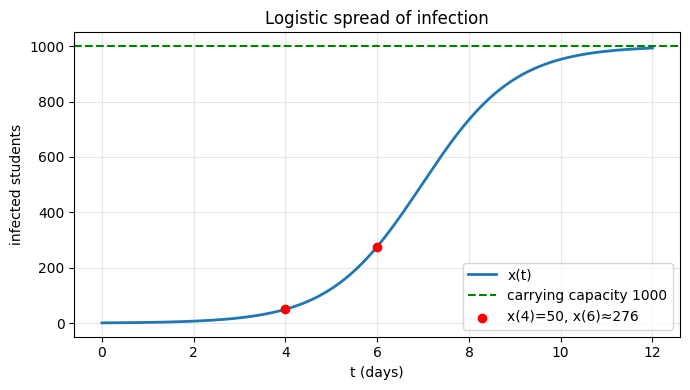

In [2]:
import numpy as np
import matplotlib.pyplot as plt

days = np.linspace(0, 12, 200)
infected = 1000 / (1 + 999 * np.exp(-0.9906 * days))

plt.figure(figsize=(7, 4))
plt.plot(days, infected, linewidth=2, label="x(t)")
plt.axhline(1000, color="green", linestyle="--", label="carrying capacity 1000")
plt.scatter([4, 6], [50, 276], color="red", zorder=5, label="x(4)=50, x(6)≈276")
plt.xlabel("t (days)"); plt.ylabel("infected students"); plt.title("Logistic spread of infection")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.show()

**References:**

[📘 Zill, D. G. (2016). *A First Course in Differential Equations with Modeling Applications* (11th ed.). Cengage Learning.](https://www.cengage.com/c/a-first-course-in-differential-equations-with-modeling-applications-11e-zill/9781305965720/)

---

[⬅️ Previous: Mixtures](./03_mixtures.ipynb) | [Next: Preliminary Theory of Linear Equations ➡️](../04_Higher_Order_Linear_Equations/01_preliminary_theory_of_linear_equations.ipynb)